In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Install requirements

# !pip install pydicom opencv-python-headless numpy matplotlib pillow
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.8 MB/s eta 0:00:00


In [7]:
# import pydicom
import numpy as np
from PIL import Image # from pillow import class image
import matplotlib.pyplot as plt
import os
import cv2
from google.colab import drive
import pandas as pd # rad sa tabelarnim podacima
import torch # tenozori
import tensorflow as tf # Use tf to read images because Pillow causes problems > ja nisam imala problema
import matplotlib.pyplot as plt # vizualziacija slika
from sklearn.model_selection import train_test_split # podela podataka random
import pydicom

#### NO need to run

In [ ]:
%cd /content
!rm -rf AllDICOMs/

/content


#### NO need to run DICOM > PNG

- already done
- the file is located: /content/drive/MyDrive/Projects/DeepLearningMaster/DICOMtoPNG

In [ ]:
# DICOM Images to PNG

# input directory = where the DICOMs are
# output directory = where should PNGs be placed

def get_names(path):
  names = []  # list
  for dirpath, dirnames, filenames in os.walk(path):
    # print(f"Current directory: {dirpath}")
    # print(f'Filenames: {filenames}')  # this prints all names of pictures in AIIDICOM folder
    for filename in filenames:
      root, ext = os.path.splitext(filename)
      if ext in ['.dcm']:
        names.append(filename)
  return names  # povratna vrednost je lista sa imenima sivh fajlova koje sadrzi

def convert_dcm_png(png_path, dcm_path):
  im = pydicom.dcmread(dcm_path)
  new_image = im.pixel_array.astype(float) # float
  scaled_image = (np.maximum(new_image,0)/new_image.max()) * 255.0 # float pixels
  scaled_image = np.uint8(scaled_image) # integer pixels > from float to uint
  final_image = Image.fromarray(scaled_image) # PIL image!

  # cv2.imwrite(png_path, final_image) > ovo ne moze jer koristi numpy array

  final_image.save(png_path)
  return final_image

output_dir = '/content/DICOMtoPNG' # forward slash
input_dir = "/content/drive/MyDrive/Projects/INBreast/INBreast/AllDICOMs"
# Create the directory if it doesn't exist,
os.makedirs(output_dir, exist_ok=True)
names = get_names(input_dir)
print(f"The number of found DICOM files is: {len(names)}")

for index, name in enumerate(names):
    dcm_path = os.path.join(input_dir, name)
    png_path = os.path.join(output_dir, name.replace(".dcm", ".png"))

    # Preskoči ako je već konvertovan
    if os.path.exists(png_path):
      print('File already converted to PNG')
      continue
    try:
        convert_dcm_png(png_path, dcm_path)
    except Exception as e:
        print(f"Error on file: {name}: {e}")
        continue

    if (index + 1) % 20 == 0:
        print(f"Converted {index +1}/{len(names)}")
        print("Conversion complete!")

print(f"PNG are saved in:{output_dir}")


The number of found DICOM files is: 410
Converted 20/410
Conversion complete!
Converted 40/410
Conversion complete!
Converted 60/410
Conversion complete!
Converted 80/410
Conversion complete!
Converted 100/410
Conversion complete!
Converted 120/410
Conversion complete!
Converted 140/410
Conversion complete!
Converted 160/410
Conversion complete!
Converted 180/410
Conversion complete!
Converted 200/410
Conversion complete!
Converted 220/410
Conversion complete!
Converted 240/410
Conversion complete!
Converted 260/410
Conversion complete!
Converted 280/410
Conversion complete!
Converted 300/410
Conversion complete!
Converted 320/410
Conversion complete!
Converted 340/410
Conversion complete!
Converted 360/410
Conversion complete!
Converted 380/410
Conversion complete!
Converted 400/410
Conversion complete!
PNG are saved in:/content/DICOMtoPNG


In [ ]:
# COPY
os.makedirs(output_dir, exist_ok=True)
!cp -r /content/DICOMtoPNG "/content/drive/MyDrive/Projects/DeepLearningMaster/DICOMtoPNG"

#### Start from here
1. check if you mounted Drive (or where you keep files)
2. check if you ran install pydicom
3. check if you ran all the imports

In [8]:
# Path to INbreast folder containing INbreast.xls and an 'images' folder with all DICOM images converted to PNG

os.chdir('/content')

# Give path to your main directory
PATH = "/content/drive/MyDrive/Projects/INBreast"

# Path to your DICOM > PNG images
test_list = [ f for f in os.listdir(PATH+"/PreprocessedDataBase") if f.endswith('.png')]
test_list.sort() # sort it in ascending order by default
len(test_list)
# print(test_list)

410

In [9]:
# Create lists for pandas df
fname = []
patients = []
views = []
sides = []
ran = range(len(test_list)) # tipa range [0, 410]
print(ran)

for i in range(len(test_list)): # 0 do 410
    l = test_list[i].split("_")
    # print(l)
    # l = ['53581124', '3be876aecfaad4ca', 'MG', 'L', 'ML', 'ANON.png']
    fname.append(l[0]) # broj
    # print(fname)
    patients.append(l[1]) # broj pacijenta
    sides.append(l[3]) # strana
    views.append(l[4]) # pogled

df = pd.DataFrame(list(zip(fname, patients, sides, views, test_list)),
                  columns=['image_id', 'patient_id', 'side', 'view', 'filename'])
print(df)

range(0, 410)
     image_id        patient_id side view  \
0    20586908  6c613a14b80a8591    R   CC   
1    20586934  6c613a14b80a8591    L   CC   
2    20586960  6c613a14b80a8591    R   ML   
3    20586986  6c613a14b80a8591    L   ML   
4    20587054  b6a4f750c6df4f90    R   CC   
..        ...               ...  ...  ...   
405  53587599  11e6732579acf692    L   CC   
406  53587663  5fb370d4c1c71974    R   CC   
407  53587690  5fb370d4c1c71974    L   ML   
408  53587717  5fb370d4c1c71974    R   ML   
409  53587744  5fb370d4c1c71974    L   CC   

                                       filename  
0    20586908_6c613a14b80a8591_MG_R_CC_ANON.png  
1    20586934_6c613a14b80a8591_MG_L_CC_ANON.png  
2    20586960_6c613a14b80a8591_MG_R_ML_ANON.png  
3    20586986_6c613a14b80a8591_MG_L_ML_ANON.png  
4    20587054_b6a4f750c6df4f90_MG_R_CC_ANON.png  
..                                          ...  
405  53587599_11e6732579acf692_MG_L_CC_ANON.png  
406  53587663_5fb370d4c1c71974_MG_R_CC_ANON.p

In [10]:
# ucitavanje INbreast.xsl

# pandas read_exel()
df_xls = pd.read_excel(
    PATH + "/INBreast/INbreast.xls",
    dtype={'File Name': str},
    usecols=["File Name", "Bi-Rads", "Acquisition date", "Laterality", "View"])

# index_col definise koja ce kolona biti index
print(df_xls)

# Lets filter last 2 rows
df_xls = df_xls[:-2] # odbacujem poslednje dve kolone jer nisu potrebne
df_xls = df_xls.rename(columns={"File Name": "image_id", "Acquisition date": "date"})

print('-------------------------------------------------')
print('Excluding last 2 cells')
print('-------------------------------------------------')
print(df_xls)
print(len(df_xls))

    Laterality View  Acquisition date File Name Bi-Rads
0            R   CC          200902.0  20586908       2
1            L   CC          200902.0  20586934       5
2            R  MLO          200902.0  20586960       2
3            L  MLO          200902.0  20586986       5
4            R   CC          200902.0  20587054      4c
..         ...  ...               ...       ...     ...
407          L  MLO          201001.0  53587690       1
408          R  MLO          201001.0  53587717       2
409          L   CC          201001.0  53587744       1
410        NaN  NaN               NaN       NaN     NaN
411        NaN  NaN               NaN       NaN      49

[412 rows x 5 columns]
-------------------------------------------------
Excluding last 2 cells
-------------------------------------------------
    Laterality View      date  image_id Bi-Rads
0            R   CC  200902.0  20586908       2
1            L   CC  200902.0  20586934       5
2            R  MLO  200902.0  205869

In [22]:
# Add 'label' columns from BI-RADS categories
# ovo je za BI-RADS u binary label

label = []
lista = []

# Itterate through DatFrames through iterrows
for index, row in df_xls.iterrows():
    birads = row["Bi-Rads"]
    # print(birads)
    if (type(birads) is str): # ako ima 4a
        birads = int(birads[0])
    lista.append(birads)
    # MAPIPING BIRADS
    if birads == 1:
      label.append(0)
    elif birads == 2: # benign
      label.append(1)
    elif birads == 3:
      label.append(2)
    elif birads == 4:
      label.append(3)
    elif birads == 5 or birads == 6:
      label.append(4)
    else:
      label.append(-1)

df_xls["label"] = label

print(label)
print("*************************************")
print(lista)

counter=0
for item in lista:
  if item == 5:
    counter+=1
print(counter)

counter1=0
for item in lista:
  if item == 4:
    counter1+=1
print(counter1)

counter2=0
for item in lista:
  if item == 6:
    counter2+=1
print(counter2)

from collections import Counter
Counter(lista)


[1, 4, 1, 4, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 2, 2, 2, 2, 2, 2, 4, 1, 4, 1, 0, 0, 3, 3, 2, 2, 1, 1, 4, 4, 1, 2, 1, 4, 1, 4, 4, 1, 4, 1, 1, 3, 1, 3, 1, 4, 1, 4, 2, 0, 2, 0, 1, 1, 1, 1, 1, 4, 1, 4, 4, 1, 4, 1, 1, 4, 1, 4, 4, 1, 4, 0, 3, 0, 3, 0, 4, 1, 4, 1, 4, 4, 1, 4, 1, 4, 1, 3, 1, 3, 4, 1, 4, 1, 3, 1, 3, 1, 0, 4, 0, 4, 1, 0, 1, 0, 3, 1, 4, 1, 3, 3, 1, 1, 1, 1, 0, 2, 0, 2, 1, 1, 1, 1, 3, 1, 3, 1, 0, 1, 0, 1, 4, 1, 4, 4, 2, 4, 2, 3, 3, 3, 3, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 4, 0, 4, 0, 1, 3, 1, 3, 3, 1, 3, 1, 1, 4, 1, 4, 1, 1, 1, 1, 1, 3, 1, 3, 4, 0, 4, 0, 1, 3, 1, 3, 1, 4, 1, 4, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 3, 0, 3, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 0, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 1, 1, 1, 1, 2, 2, 2, 2, 1, 4, 1, 4, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 4, 4, 1, 0, 1, 0, 1, 0, 1, 0, 4, 4, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 

Counter({2: 220, 5: 49, 4: 43, 3: 23, 6: 8, 1: 67})

In [23]:
# Merge the two dataframes
merged_df = pd.merge(df, df_xls, how='left', on=['image_id'])
merged_df = merged_df.filter(["image_id", "patient_id", "side", "View", "filename", "date", "Bi-Rads","label"])
merged_df = merged_df.rename(columns={"View": "view", "Bi-rads": "birads"})
merged_df = merged_df.sort_values(by=["patient_id", "date", "side", "view"])
merged_df = merged_df[merged_df.view.isin(["CC", "MLO"])]
len(merged_df)

409

In [24]:
# Handle cases of same patient with multiple exams (different dates)
# + remove cases that don't have two views
# + if num_views = 4, remove cases that don't have 4 views
# + remove label=-1 aka birads=3

def clean_df(df, num_views=2):
    grouped = df.groupby(["patient_id", "side", "view"])
    for name, group in grouped:
        # if there is more than 1 date
        if len(set(group["date"])) > 1:
            date_max = max(group["date"])
            df = df.drop(group[group.date != date_max].index)

        # if there isn't more than 1 date but there are still multiple images
        # aka there is a duplicate
        elif len(group) > 1:
            df = df.drop(list(group.index)[-1])

    grouped = df.groupby(["patient_id", "side"])
    for name, group in grouped:
        if len(group) < 2:
            df = df.drop(index=group.index)

    df = df[df.label.isin([0, 1, 2, 3, 4])]

    if num_views == 4:
        grouped = df.groupby(["patient_id", "view"])
        for name, group in grouped:
            if (len(group) < 2):
                df = df.drop(index=group.index)

    df = df.sort_values(by=["patient_id", "side", "view"])
    df = df.reset_index(drop=True)
    return df


In [25]:
two_views_df = clean_df(merged_df, num_views=2)
four_views_df = clean_df(merged_df, num_views=4)
len(two_views_df), len(four_views_df)
# # print(len(two_views_df))
# # print(len(four_views_df))
# print(two_views_df["label"])
# two_views_df

(374, 320)

# You can start from Data Frames

In [ ]:
# Save dataframes
two_views_df.to_pickle("/content/drive/MyDrive/Projects/DeepLearningMaster/DataFramesPreprocessing/two_views_birads_df.pkl")
# four_views_df.to_pickle(f"{PATH}/four_views_df.pkl")

In [29]:
SEED = 42
NUM_VIEWS = 2
assert NUM_VIEWS in [2, 4]
# Define/load dataframe

if NUM_VIEWS == 2:
    df = two_views_df
    # df = pd.read_pickle("/content/drive/MyDrive/Projects/DeepLearningMaster/DataFramesPreprocessing/two_views_birads_df.pkl")
else:
    df = four_views_df
    # df = pd.read_pickle(f"{SAVE_PATH}/four_views_df.pkl")

len(df)

374

In [30]:
# Set the num of views to be 2
if NUM_VIEWS == 2:
    X, y = [], []
    grouped = df.groupby(["patient_id", "side"])
    for name, group in grouped:
        X.append(name[0] + "_" + name[1])
        y.append(list(group['label'])[0])
else:
    X = df.patient_id.unique().tolist()


In [31]:
from collections import Counter

if NUM_VIEWS == 2:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
else:
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)

print(f"Train: {len(X_train)} uzoraka")
print(f"Val: {len(X_test)} uzoraka")
print("---")
print(f"X train:{X_train}")
print(f"X test:{X_test}")
print(f"Y train:{y_train}")
print(f"Y test:{y_test}")
print("******")
print(f"Y train distribution: {Counter(y_train)}")
print(f"Y test distribution: {Counter(y_test)}")

Train: 130 uzoraka
Val: 57 uzoraka
---
X train:['64a22c47765f0c5c_L', '069212ec65a94339_L', '51bec6477a7898b9_R', '3be876aecfaad4ca_L', 'c94d8a1ebd452afe_L', '6c613a14b80a8591_L', 'f571fd4e63c718e3_L', 'dcafa6ba6374ec07_L', '301f1776aebbf5d2_L', '6200187f3f1ccc18_R', '97ec8cadfca70d32_L', '66adfbb4f19c76d2_R', '573747ee33ef6e5a_L', 'b03f1dd34eb3c55f_L', 'd742ec2f9b90aa62_L', '61b13c59bcba149e_R', '5fb370d4c1c71974_R', 'cd12bc20b3d27d0b_L', '6f64793857feb5d0_L', '4c341dad22471922_R', '8913a7e0cf3bd74e_R', 'cd12bc20b3d27d0b_R', '98429c0bdf78c0c7_R', '61b13c59bcba149e_L', '330e5fe16929eed4_R', '81cd83d2f4d78528_R', '9e8db9e34d5275ef_R', '839819f2eadaf325_L', 'bbd6a3a35438c11b_L', 'f4b2d377f43ba0bd_R', '5eae9beae14d26fd_R', 'de4c34099d6ef8de_R', '6bd24a0a42c19ce1_L', 'ce5e5e18a261cd29_L', '301f1776aebbf5d2_R', 'fbb55bf7fff48540_R', '71c1a60d57c5322f_L', 'e1f51192f7bf3f5f_R', '4c341dad22471922_L', 'bbd6a3a35438c11b_R', 'f3e93e889a7746f0_L', '3f22cdda8da215e3_R', '809e3f43339f93c6_L', '1f139

In [32]:
# Read and resize image
def get_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img)
    img = tf.image.resize(img, (600, 500))
    img = np.asarray(img).squeeze()
    return img

# Load all data into memory (for faster training)
def load_data(images_path, pat_list, df, num_views):
    data = []
    pos = 0

    for elem in pat_list:
        if num_views == 2:
            pat_id, side = elem.split("_")
            pat_df = df[(df.patient_id==pat_id) & (df.side==side)]
        else:
            pat_id = elem
            pat_df = df[df.patient_id==pat_id]


        cc_name = pat_df.loc[pat_df.view=='CC', 'filename'].tolist()
        mlo_name = pat_df.loc[pat_df.view=='MLO', 'filename'].tolist()

        cc_image = get_image(images_path + '/' + cc_name[0])
        mlo_image = get_image(images_path + '/' + mlo_name[0])

        if num_views == 2:
            image = np.stack([cc_image, mlo_image])
            label = pat_df['label'].tolist()[0]

            if label == 1:
                pos += 1
        else:
            r_cc_image = np.flip(get_image(images_path + '/' + cc_name[1]), axis=1)
            r_mlo_image = np.flip(get_image(images_path + '/' + mlo_name[1]), axis=1)
            image = np.stack((cc_image, mlo_image, r_cc_image, r_mlo_image))

            label_sx = pat_df['label'].tolist()[0]
            label_dx = pat_df['label'].tolist()[2]
            label = (label_sx, label_dx)

            if label_sx == 1:
                pos += 1

            if label_dx == 1:
                pos += 1

        data.append([torch.FloatTensor(image), label])
        # data = [image_tensor, label]
    return data

def plot_exam(exam, num_views):
    print("Images have shape: ", exam.shape)
    fig, axes = plt.subplots(1, num_views)
    axes[0].imshow(exam[0, :, :], cmap="gray")
    axes[1].imshow(exam[1, :, :], cmap="gray")
    if num_views == 4:
        axes[2].imshow(exam[2, :, :], cmap="gray")
        axes[3].imshow(exam[3, :, :], cmap="gray")


In [33]:
# load_data(images_path, pat_list, df, num_views)
train_data = load_data("/content/drive/MyDrive/Projects/DeepLearningMaster/DICOMtoPNG", X_train, df, NUM_VIEWS)
test_data = load_data("/content/drive/MyDrive/Projects/DeepLearningMaster/DICOMtoPNG", X_test, df, NUM_VIEWS)
print("Len train: ", len(train_data))
print("Len test: ", len(test_data))
tot_train = len(train_data) if NUM_VIEWS == 2 else len(train_data)*2
tot_test = len(test_data) if NUM_VIEWS == 2 else len(test_data)*2


Len train:  130
Len test:  57


In [34]:
print(type(train_data))
print(type(X_train))

<class 'list'>
<class 'list'>


In [35]:
# get the label of the patient number 5 (0-indexing in Python)
label = train_data[6][1]
print(label)

3


In [44]:
label = train_data[5][1]
print('Birads')
print(label+1)

Birads
5


Images have shape:  torch.Size([2, 600, 500])


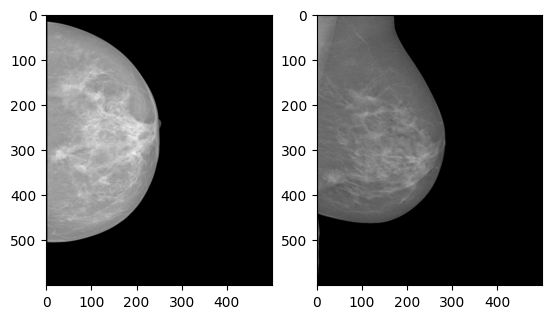

In [45]:
plot_exam(train_data[5][0], num_views=NUM_VIEWS)


In [50]:
patiend_id = 7

In [51]:
label = train_data[patiend_id][1]
print('Birads')
print(label+1)

Birads
5


The number of views is: 2
Images have shape:  torch.Size([2, 600, 500])


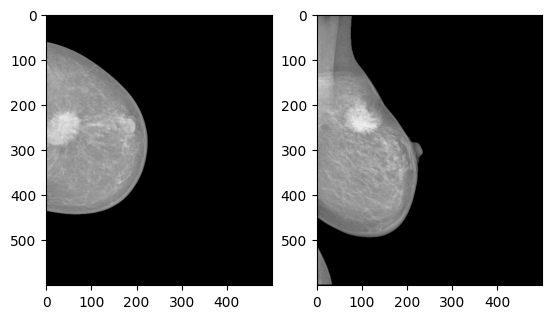

In [52]:
print(f"The number of views is: {NUM_VIEWS}")
plot_exam(train_data[patiend_id][0], num_views=NUM_VIEWS)


Images have shape:  torch.Size([2, 600, 500])


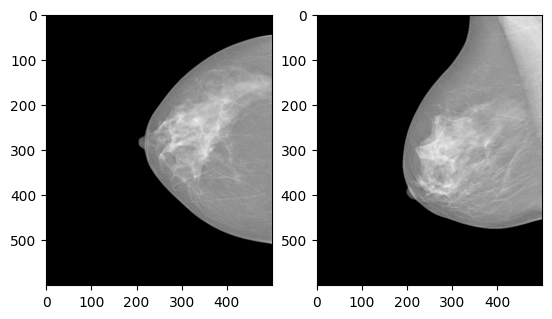

In [ ]:
plot_exam(test_data[0][0], num_views=NUM_VIEWS)


Images have shape:  torch.Size([2, 600, 500])


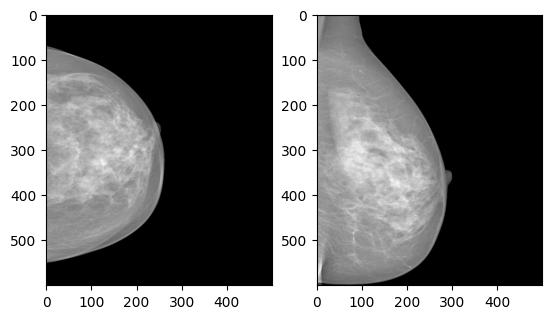

In [ ]:
plot_exam(train_data[100][0], num_views=NUM_VIEWS)


Found BIRADS 2
Found BIRADS 1
Found BIRADS 5
Found BIRADS 4
Found BIRADS 3
done


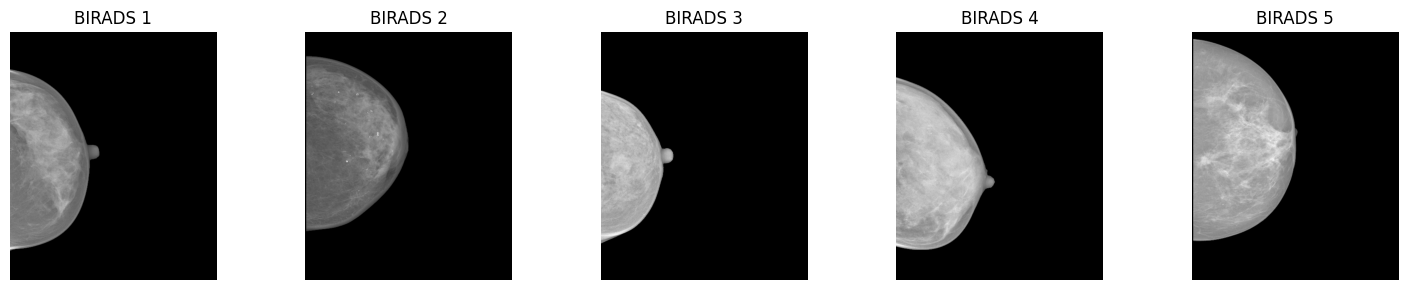

In [58]:
# Collect one example image per BIRADS category
found = {}                      # {label: image_tensor}
target_labels = range(0, 5)     # labels 0-4 -> BIRADS 1-5

for data in train_data:
    image, label = data

    if label not in found:
        found[label] = image
        print(f"Found BIRADS {label+1}")

    if len(found) == len(target_labels):   # stop once all 5 are collected
        print("done")
        break

# Plot one view (CC) per category, side by side
fig, axes = plt.subplots(1, len(found), figsize=(15, 3))

for i, (label, image) in enumerate(sorted(found.items())):
    axes[i].imshow(image[0], cmap="gray")   # image[0] = CC view (first in the stack)
    axes[i].set_title(f"BIRADS {label+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Save data
save_path ="/content/drive/MyDrive/Projects/DeepLearningMaster/BiradsPreprocessedIM"
os.makedirs(save_path, exist_ok=True)

torch.save(train_data, f"{save_path}/training_{NUM_VIEWS}views.pt")
torch.save(test_data, f"{save_path}/validation_{NUM_VIEWS}views.pt")

DATASET STATISTIKE
Training samples: 130
Validation samples: 57

--- PRVI SAMPLE ---
Image shape: torch.Size([2, 600, 500])
Image dtype: torch.float32
Image range: [0.000, 247.098]
Label: 1
Label type: <class 'int'>

--- LABEL DISTRIBUCIJA ---
Label 0:   21 samples (16.15%)
Label 1:   68 samples (52.31%)
Label 2:    8 samples ( 6.15%)
Label 3:   14 samples (10.77%)
Label 4:   19 samples (14.62%)


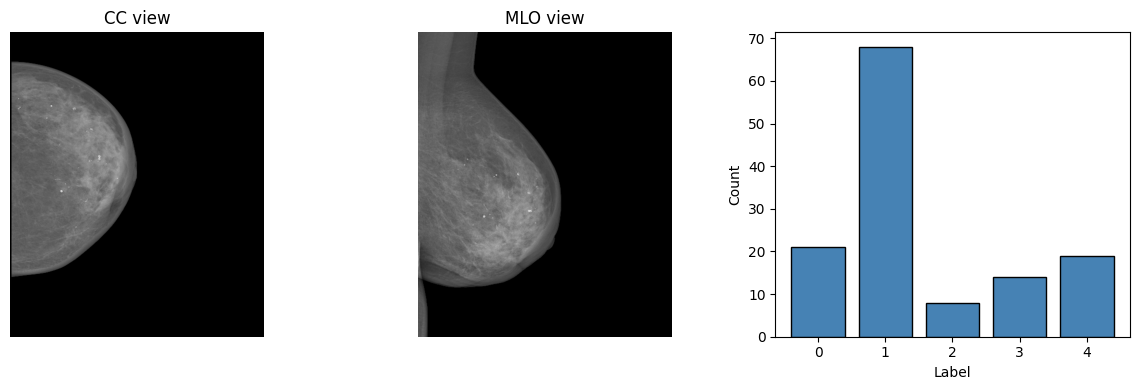


✅ Data inspection complete!
✅ Figure saved: data_inspection.png


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Load training data
train_data = torch.load("/content/drive/MyDrive/Projects/DeepLearningMaster/BiradsPreprocessedIM/training_2views.pt")
val_data = torch.load("/content/drive/MyDrive/Projects/DeepLearningMaster/BiradsPreprocessedIM/validation_2views.pt")

print("="*60)
print("DATASET STATISTIKE")
print("="*60)
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
# print(f"Test samples: {len(test_data)}")

# Pogledaj prvi sample
sample_img, sample_label = train_data[0]

print(f"\n--- PRVI SAMPLE ---")
print(f"Image shape: {sample_img.shape}")
print(f"Image dtype: {sample_img.dtype}")
print(f"Image range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
print(f"Label: {sample_label}")
print(f"Label type: {type(sample_label)}")

# Label distribucija
train_labels = [label.item() if torch.is_tensor(label) else label
                for _, label in train_data]

label_counts = Counter(train_labels)

print(f"\n--- LABEL DISTRIBUCIJA ---")
for label in sorted(label_counts.keys()):
    count = label_counts[label]
    percentage = 100 * count / len(train_labels)
    print(f"Label {label}: {count:4d} samples ({percentage:5.2f}%)")

# Visualize prvi sample
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
if len(sample_img.shape) == 3 and sample_img.shape[0] == 2:
    # Ako imaš (CC, MLO) parove
    plt.imshow(sample_img[0].cpu(), cmap='gray')
    plt.title('CC view')
elif len(sample_img.shape) == 2:
    plt.imshow(sample_img.cpu(), cmap='gray')
    plt.title('Single image')
else:
    plt.imshow(sample_img[0].cpu(), cmap='gray')
    plt.title('First channel')
plt.axis('off')

plt.subplot(1, 3, 2)
if len(sample_img.shape) == 3 and sample_img.shape[0] == 2:
    plt.imshow(sample_img[1].cpu(), cmap='gray')
    plt.title('MLO view')
plt.axis('off')

plt.subplot(1, 3, 3)
labels_list = list(label_counts.keys())
counts_list = [label_counts[l] for l in labels_list]
plt.bar(labels_list, counts_list, color='steelblue', edgecolor='black')
plt.xlabel('Label')
plt.ylabel('Count')
# plt.title('Label Distribution')
plt.xticks(labels_list)

plt.tight_layout()
plt.savefig('data_inspection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Data inspection complete!")
print("✅ Figure saved: data_inspection.png")

### Quick check of our data

In [ ]:
# train_data = torch.load(f"{save_path}/training_2views.pt")
# test_data  = torch.load(f"{save_path}/validation_2views.pt")

print(len(train_data), len(test_data))          # should match your 130 / 57 (or whatever your final counts are)

img, label = train_data[0]                        # each element is an (image, label) tuple, per load_data's structure
print(img.shape, img.dtype, img.min(), img.max())   # shape should be (2, 600, 500) — CC+MLO stacked
print(label, type(label))                          # should be an int 0-4, not a tensor, not the raw BI-RADS value

130 57
torch.Size([2, 600, 500]) torch.float32 tensor(0.) tensor(247.0982)
1 <class 'int'>


#### Examples

In [ ]:
import torch
loss = torch.nn.CrossEntropyLoss()
out = torch.randn(1, 6)   # fake model output, 6 classes
print(out)
target = torch.tensor([6])  # label = 6, unmodified
print(target)
# loss(out, target)

tensor([[ 0.5870,  0.0167, -0.3265,  1.1397,  1.5560,  0.1877]])
tensor([6])


####  What does it mean one independent sigmoid per label ?

This criterion computes the cross entropy loss between input logits and target... useful when training a classification problem with C classes.

Explain both of these phrases, what does it mean

# Checking the .pt tensor is birads or binary


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import torch

# data = torch.load("/content/drive/MyDrive/Projects/DeepLearningMaster/BiradsPreprocessedIM/training_2views.pt", map_location="cpu")
# # structure depends on how you saved it - likely a dict or a Dataset/TensorDataset
# # if it's a dict with a 'labels' key, or a dataset object with .targets/.labels:
# labels = data["labels"] if isinstance(data, dict) else print("bad")  # adjust to your actual structure

# print("Unique label values:", torch.unique(labels))
# print("Number of unique classes:", len(torch.unique(labels)))

import torch
from collections import Counter

path = "/content/drive/MyDrive/Projects/DeepLearningMaster/BiradsPreprocessedIM/training_2views.pt"  # e.g. training_2views.pt
data = torch.load(path, map_location="cpu")

print("Type of loaded object:", type(data))
print("Number of samples:", len(data))

# Pull out just the labels, handling both 2-view (scalar) and 4-view (tuple) cases
labels = []
for item in data:
    _, label = item
    if isinstance(label, tuple):
        labels.extend(label)   # 4-view: unpack (label_sx, label_dx)
    else:
        labels.append(label)   # 2-view: scalar

label_counts = Counter(labels)
distinct_values = sorted(label_counts.keys())

print("Distinct label values found:", distinct_values)
print("Counts per value:", dict(label_counts))

Type of loaded object: <class 'list'>
Number of samples: 130
Distinct label values found: [0, 1, 2, 3, 4]
Counts per value: {1: 68, 0: 21, 4: 19, 3: 14, 2: 8}
